# Rubin alert archive in HATS

This notebook explores the Rubin alert archive and its transformation into HATS.

In [11]:
import lsdb
import pyarrow as pa
import pyarrow.compute as pc

from dask.distributed import Client
from hats_import import pipeline_with_client
from hats_import.catalog.arguments import ImportArguments
from hats_import.catalog.file_readers import ParquetPyarrowReader
from upath import UPath

### What we know

- There are currently ~13M alerts since Nov 2025 (according to [Fink](https://lsst.fink-portal.org/stats)):
    <img src="images/fink_stats.png" width="800"/>
- The alert packet format is defined in [sqr-114.lsst.io/v/DM-54197](https://sqr-114.lsst.io/v/DM-54197/index.html#alert-packet-format).
- The alerts are stored in compressed AVRO Confluent Wire Format (`.avro.gz`):
    ```bash
    Byte 0:     0x00          - magic byte, identifies Confluent Wire Format
    Bytes 1-4:  <uint32 BE>   - schema ID
    Bytes 5+:   <avro binary> - Avro-encoded record (no schema embedded)
    ```
- Each alert is stored in its individual file on disk. The files are named after the `alertId` (`diaSourceId`) of the alert it stores.

- An alert is encoded with a specific `schema`. There are currently two schemas - ID: `1000` and `1100`. The most recent schema, `1100` is backwards compatible with the previous one, since it only changes the nullability to some fields, which arrow already supports by default.

- The alerts are stored in `/sdf/data/rubin/shared/alert-archive/v2/alerts`.

- The schemas are stored in `/sdf/data/rubin/shared/alert-archive/v2/schemas`.

### Processing an alert file

Below is an example of reading with `fastavro` and converting to arrow with `avrotize`.

In [12]:
apdb_path = UPath("/sdf/data/rubin/shared/alert-archive/v2")

In [13]:
import fastavro
import json

from avrotize.avrotoparquet import AvroToParquetConverter

def load_input_schemas():
    """Load all AVRO schemas from files into a cache"""
    avro_schemas, arrow_schemas = {}, {}
    for path in (apdb_path / "schemas").glob("*.json"):
        schema_id = int(path.stem)
        with open(path) as f:
            schema = fastavro.parse_schema(json.load(f))
        avro_schemas[schema_id] = schema
        arrow_schemas[schema_id] = avro2arrow(schema)
    print(f"Found {len(avro_schemas)} schemas: {avro_schemas.keys()}")
    return avro_schemas, arrow_schemas

def avro2arrow(avro_schema):
    """Converts avro schemas into arrow schemas"""
    converter = AvroToParquetConverter()
    converter.cache_named_types(avro_schema)
    return pa.schema([
        pa.field(f["name"], converter.convert_avro_type_to_parquet_type(f["type"]))
        for f in avro_schema["fields"]
    ])

avro_schemas, arrow_schemas = load_input_schemas()

Found 2 schemas: dict_keys([1000, 1100])


In [14]:
from deepdiff import DeepDiff
print(DeepDiff(avro_schemas[1000], avro_schemas[1100], verbose_level=2).pretty())

Type of root['fields'][3]['type']['fields'][27]['type'] changed from list to str and value changed from ['null', 'int'] to "int".
Type of root['fields'][3]['type']['fields'][42]['type'] changed from list to str and value changed from ['null', 'int'] to "int".
Type of root['fields'][3]['type']['fields'][51]['type'] changed from list to str and value changed from ['null', 'int'] to "int".
Type of root['fields'][3]['type']['fields'][76]['type'] changed from list to str and value changed from ['null', 'int'] to "int".
Type of root['fields'][6]['type'][1]['fields'][10]['type'] changed from list to str and value changed from ['null', 'int'] to "int".
Type of root['fields'][6]['type'][1]['fields'][16]['type'] changed from list to str and value changed from ['null', 'int'] to "int".
Type of root['fields'][6]['type'][1]['fields'][22]['type'] changed from list to str and value changed from ['null', 'int'] to "int".
Type of root['fields'][6]['type'][1]['fields'][28]['type'] changed from list to s

In [15]:
import io
import gzip
import struct

def read_alert(path):
    """Read single alert file"""
    with gzip.open(path, "rb") as f:
        data = f.read()
    schema_id = struct.unpack(">I", data[1:5])[0]
    chunk = fastavro.schemaless_reader(io.BytesIO(data[5:]), avro_schemas[schema_id])
    return pa.Table.from_pylist([chunk], schema=arrow_schemas[schema_id])

read_alert("/sdf/data/rubin/shared/alert-archive/v2/alerts/17006/170063701495775239.avro.gz").schema

diaSourceId: int64
observation_reason: string
target_name: string
diaSource: struct<diaSourceId: int64, visit: int64, detector: int32, diaObjectId: int64, ssObjectId: int64, par (... 2046 chars omitted)
  child 0, diaSourceId: int64
  child 1, visit: int64
  child 2, detector: int32
  child 3, diaObjectId: int64
  child 4, ssObjectId: int64
  child 5, parentDiaSourceId: int64
  child 6, midpointMjdTai: double
  child 7, ra: double
  child 8, raErr: float
  child 9, dec: double
  child 10, decErr: float
  child 11, ra_dec_Cov: float
  child 12, x: float
  child 13, xErr: float
  child 14, y: float
  child 15, yErr: float
  child 16, centroid_flag: bool
  child 17, apFlux: float
  child 18, apFluxErr: float
  child 19, apFlux_flag: bool
  child 20, apFlux_flag_apertureTruncated: bool
  child 21, isNegative: bool
  child 22, snr: float
  child 23, psfFlux: float
  child 24, psfFluxErr: float
  child 25, psfLnL: float
  child 26, psfChi2: float
  child 27, psfNdata: int32
  child 28, psfFl

We can create a custom file reader for HATS import to ingest these files. However... 

At one alert per file we are **I/O bound**. Reading millions of files one at a time is already slow, and we would duplicate the expensive work of transforming AVRO into Arrow in both the mapping and splitting stages. 

Neven ran a separate script to create a parquet dump of aggregated alerts.

In [16]:
# Path to the alert archive dump on USDF
input_path = UPath("/sdf/data/rubin/user/ncaplar/alert-parquet")
# The output directory for the HATS collections
output_path = UPath("/sdf/data/rubin/shared/lsdb_commissioning")

We still need a custom alert reader to:
- Create base coordinate columns based on the alert DIA source ra/dec.
- Convert struct columns into lists of struct so they are inferred as nested.
- Drop the cutouts that we do not need.

In [17]:
class AlertReader(ParquetPyarrowReader):
    """Reads alert parquet files"""

    def read(self, input_file, **kwargs):
        for table in super().read(input_file):
            table = set_coordinates(table)
            table = convert_to_list_of_struct(table)
            columns_to_drop = [f for f in table.column_names if f.startswith("cutout")]
            yield table.drop_columns(columns_to_drop)

def set_coordinates(table):
    dia_source = table.column("diaSource")
    for col_name in ["dec","ra"]:
        coords = pc.struct_field(dia_source, col_name)
        table = table.add_column(0, col_name, coords)
    return table

def convert_to_list_of_struct(table):
    for i, field in enumerate(table.schema):
        if pa.types.is_struct(field.type):
            new_array = struct_to_list_of_struct(table.column(i))
            table = table.set_column(i, pa.field(field.name, new_array.type), new_array)
    return table

def struct_to_list_of_struct(array):
    array = array.combine_chunks()
    offsets = pa.array(range(len(array) + 1), type=pa.int32())
    return pa.ListArray.from_arrays(offsets, array, type=pa.list_(array.type))

Let's try the new parquet reader:

In [18]:
import nested_pandas as npd
table = next(AlertReader().read(input_path / "170587__00100000-00138048.parquet"))
npd.from_pyarrow(table).head(1)

ra        dec         diaSourceId observation_reason target_name  \
0  332.511186 -16.241371  170587115697995798      pairs_iz_33.0     lowdust   

                                           diaSource prvDiaSources  \
0  [{diaSourceId: 170587115697995798, visit: 2026...          None   

  prvDiaForcedSources                                          diaObject  
0                  []  [{diaObjectId: 170587115697995798, validitySta...

In [ ]:
args = ImportArguments(
    output_path=output_path,
    output_artifact_name="alert_archive",
    input_file_list=list(input_path.rglob("*.parquet")),
    file_reader=AlertReader(),
    pixel_threshold=100_000,
    resume=True,
)
with Client(
    n_workers=16,
    memory_limit="28GiB",
    threads_per_worker=1,
    local_directory=output_path / "dask_spill",
) as client:
    pipeline_with_client(args, client)

Let's have a quick look at the results:

In [19]:
alerts = lsdb.open_catalog(output_path / "alert_archive")
alerts

,ra,dec,diaSourceId,observation_reason,target_name,diaSource,prvDiaSources,prvDiaForcedSources,diaObject
npartitions=407,,,,,,,,,
"Order: 0, Pixel: 4",double[pyarrow],double[pyarrow],int64[pyarrow],string[pyarrow],string[pyarrow],"nested<diaSourceId: [int64], visit: [int64], d...","nested<diaSourceId: [int64], visit: [int64], d...","nested<diaForcedSourceId: [int64], diaObjectId...","nested<diaObjectId: [int64], validityStartMjdT..."
"Order: 2, Pixel: 101",...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...
"Order: 1, Pixel: 43",...,...,...,...,...,...,...,...,...
"Order: 0, Pixel: 11",...,...,...,...,...,...,...,...,...


14,946,835 alerts in the catalog


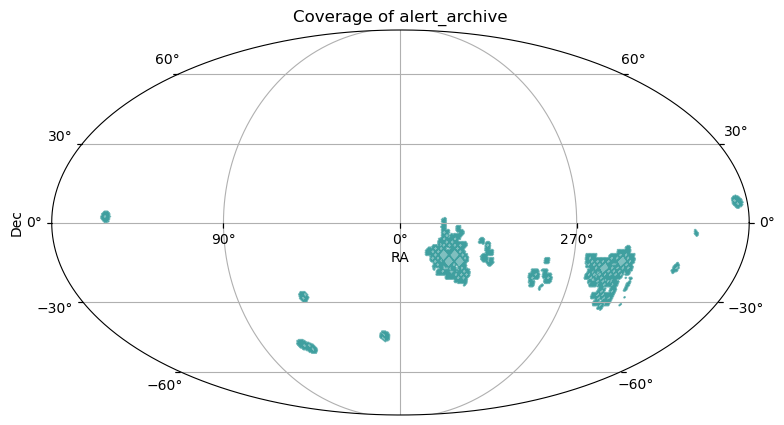

In [20]:
alerts.plot_coverage()
print(f"{len(alerts):,} alerts in the catalog")

The next step is to keep the catalog up-to-date with nightly increments.